<a href="https://colab.research.google.com/github/aricore87/aphelion/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1] A projectile is thrown at an angle in air. Determine the range and plot the path for angles 30, 35, 40, 45, 50, 55 and 60 degrees. Initial speed 100 m/s. Use Euler's method. Use numpy array.


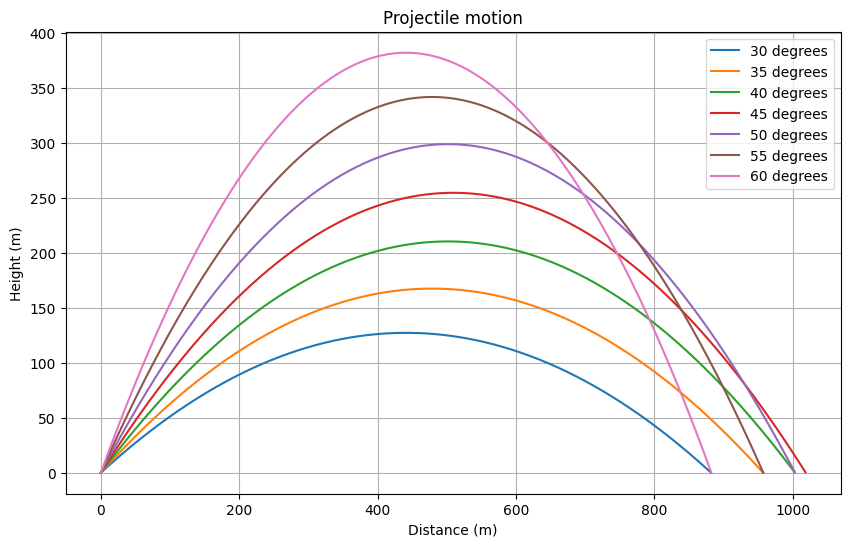

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
v0 = 100.0
g = 9.81
dt = 0.01
angles = [30,35,40,45,50,55,60]
plt.figure(figsize=(10, 6))
for angle in angles:
    theta = np.radians(angle)
    vx = v0 * np.cos(theta)
    vy_initial = v0 * np.sin(theta)
    # no of steps
    num_steps = 2500
    x= np.zeros(num_steps)
    y= np.zeros(num_steps)
    vy = vy_initial

    #Euler loop
    for i in range(1,2500):
      vy = vy - (g*dt) #velocity update
      # postion update
      x[i] = x[i-1] + vx*dt
      y[i] = y[i-1] + vy*dt
      if y[i] < 0:
        x = x[:i]
        y = y[:i]
        break
    #graph
    plt.plot(x, y, label=f'{angle} degrees') # Added label for clarity
plt.title ('Projectile motion')
plt.xlabel('Distance (m)')
plt.ylabel('Height (m)')
plt.grid(True)
plt.legend() # Added legend
plt.show()

Q2] In the above problem, add air damping coefficient of 0.01, 0.02, 0.05, 0.10, 0.20, 0.50 and get the answers. Use Euler's method, use numpy array.

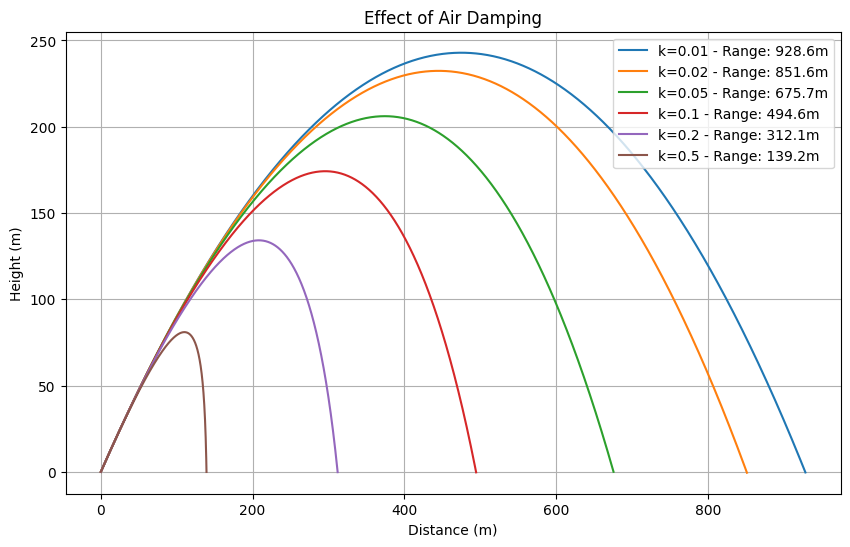

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
v0 = 100.0
g = 9.81
dt = 0.01
angle = 45 #taken as a fixed angle to see damping
a_d_coefficients = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50]

plt.figure(figsize=(10, 6))

for k in a_d_coefficients:
    theta = np.radians(angle)

    # For high damping, it hits the ground fast; for low, it takes longer.
    max_steps = 3000
    x = np.zeros(max_steps)
    y = np.zeros(max_steps)

    # Velocity
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    # Euler Loop
    for i in range(1, max_steps):
        # accelerations
        ax = -k * vx
        ay = -g - k * vy

        # velocities
        vx = vx + ax * dt
        vy = vy + ay * dt

        #  positions
        x[i] = x[i-1] + vx * dt
        y[i] = y[i-1] + vy * dt

        # to stop the loop if the projectile hits the ground
        if y[i] < 0:
            x = x[:i+1]
            y = y[:i+1]
            break

    plt.plot(x, y, label=f"k={k} - Range: {x[-1]:.1f}m")

plt.title("Effect of Air Damping")
plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.legend()
plt.grid(True)
plt.show()

Q3) Using the initial speed of 100 m/s, determine angle of projection for maximum range by trial and error method for each damping coefficient.





In [ ]:
import numpy as np
v0 = 100.0
g = 9.81
dt = 0.001
coefficients = [0.01,0.02,0.05,0.10,0.20,0.50]
test_angles = np.arange(1,90,0.5)
def get_range(angle,k):
  theta = np.radians(angle)
  vx = v0 * np.cos(theta)
  vy = v0 * np.sin(theta)
  curr_x , curr_y = 0.0,0.0
  while curr_y >=0:
    # for damping acceleration
    ax = -k * vx
    ay = -g - k * vy
    #  new velocity
    vx = vx + ax * dt
    vy = vy + ay * dt
    # update position
    curr_x = curr_x + vx * dt
    curr_y = curr_y + vy * dt
  return curr_x
print(f"{'Damping (k)':<12} | {'Max Angle':<12} | {'Max Range (m)':<15}")
print("-" * 45)
for k in coefficients:
  all_ranges = np.array([get_range(a,k)for a in test_angles])
  best_idx = np.argmax(all_ranges)
  max_range = all_ranges[best_idx]
  best_angle = test_angles[best_idx]
  print(f"{k:<12} | {best_angle:<12.1f} | {max_range:<15.2f}")


Damping (k)  | Max Angle    | Max Range (m)  
---------------------------------------------
0.01         | 43.5         | 929.96         
0.02         | 42.5         | 854.93         
0.05         | 39.5         | 688.23         
0.1          | 35.5         | 519.01         
0.2          | 30.0         | 347.20         
0.5          | 22.0         | 173.09         


4 .Take a charged particle with mass m. It is kept in Electric and Magnetic field which are parallel to each other. Determine the path of charged particle if it is initially moving with speed of 1000 m/s at 30, 45, 60 and 90 degree angles with fields. Plot 3 D graphs.Here,consider particle is electron and proton (both cases).Take magnetic field of tesla. Take electric field of 1000 V/m

/tmp/ipykernel_34848/151115341.py:25: RuntimeWarning: overflow encountered in scalar divide
  ay = (q * -vx * B_z) / m
/tmp/ipykernel_34848/151115341.py:35: RuntimeWarning: invalid value encountered in scalar add
  vy = vy + ay * dt
/tmp/ipykernel_34848/151115341.py:24: RuntimeWarning: overflow encountered in scalar divide
  ax = (q * vy * B_z) / m
/tmp/ipykernel_34848/151115341.py:34: RuntimeWarning: invalid value encountered in scalar add
  vx = vx + ax * dt
/usr/local/lib/python3.12/dist-packages/mpl_toolkits/mplot3d/proj3d.py:150: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0] / w, vecw[1] / w, vecw[2] / w


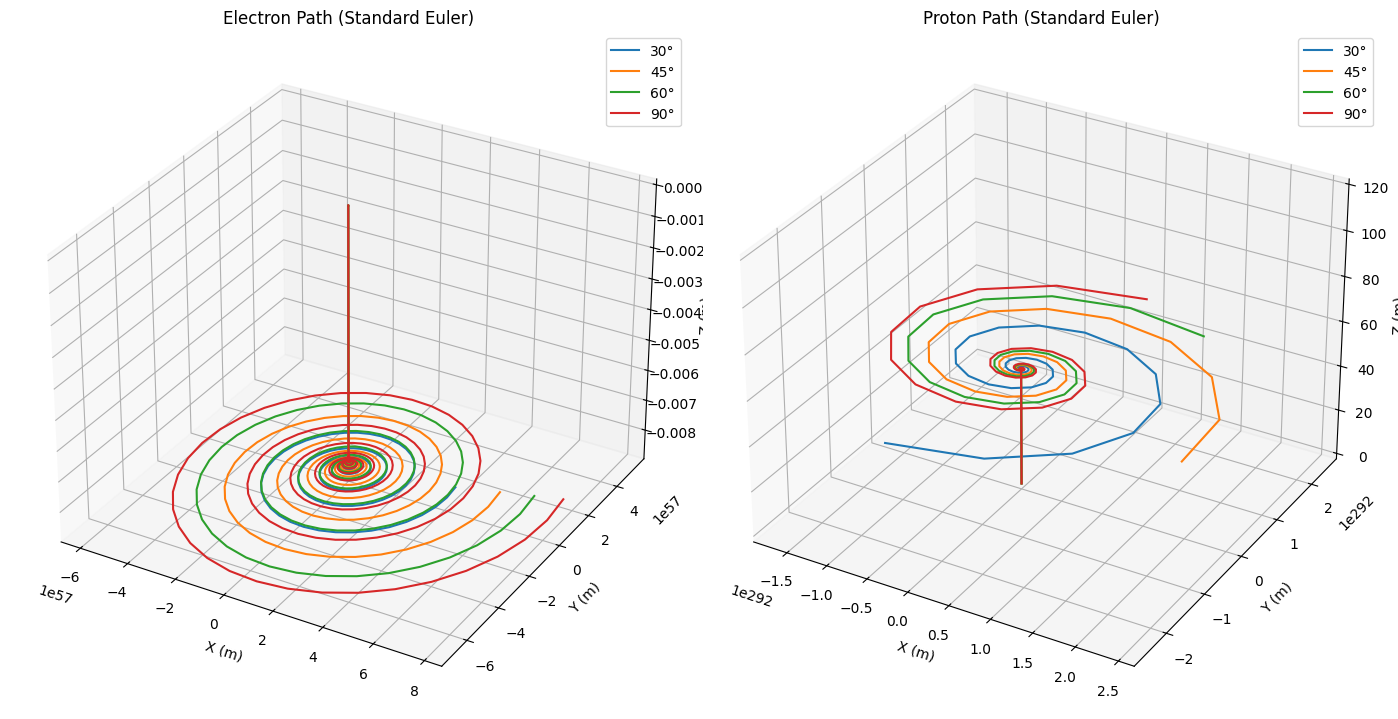

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Constants
m_e = 9.109e-31      # Mass of electron
q_e = -1.602e-19     # Charge of electron
m_p = 1.672e-27      # Mass of proton
q_p = 1.602e-19      # Charge of proton

E_z = 1000.0         # E.f (V/m) along Z
v0 = 1000.0          # Initial speed (m/s)
angles = [30, 45, 60, 90]

def get_trajectory(q, m, angle_deg, dt, steps):
    theta = np.radians(angle_deg)
    vx, vy, vz = 0.0, v0 * np.sin(theta), v0 * np.cos(theta)
    x, y, z = 0.0, 0.0, 0.0
    path = np.zeros((steps, 3))
    for i in range(steps):
        path[i] = [x, y, z]

        #ACCELERATION (F/ M)
        ax = (q * vy * B_z) / m
        ay = (q * -vx * B_z) / m
        az = (q * E_z) / m

        # Updating Position FIRST using CURRENT velocity
        x = x + vx * dt
        y = y + vy * dt
        z = z + vz * dt

        # Updating Velocity
        vx = vx + ax * dt
        vy = vy + ay * dt
        vz = vz + az * dt

    return path

# Plotting
fig = plt.figure(figsize=(14, 8))

# Electron
ax1 = fig.add_subplot(121, projection='3d')
for ang in angles:
    # Electron is very light; using smaller dt
    traj = get_trajectory(q_e, m_e, ang, 1e-12, 10000)
    ax1.plot(traj[:,0], traj[:,1], traj[:,2], label=f"{ang}°")
ax1.set_title("Electron Path (Standard Euler)")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.legend()

# Proton
ax2 = fig.add_subplot(122, projection='3d')
for ang in angles:
    # Proton is heavier; so using larger dt
    traj = get_trajectory(q_p, m_p, ang, 5e-9, 10000)
    ax2.plot(traj[:,0], traj[:,1], traj[:,2], label=f"{ang}°")
ax2.set_title("Proton Path (Standard Euler)")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.legend()

plt.tight_layout()
plt.show()

5 . Repeat this for the case when electric and magnetic fields are along X and Y axis and the above angles of velocity are with z axis.Here,consider particle is electron and proton (both cases).

/tmp/ipykernel_13383/2444789176.py:43: RuntimeWarning: overflow encountered in scalar divide
  vx = vx + (Fx / m) * dt
/tmp/ipykernel_13383/2444789176.py:39: RuntimeWarning: invalid value encountered in scalar multiply
  Fy = q * (Ey + (vz * Bx - vx * Bz))


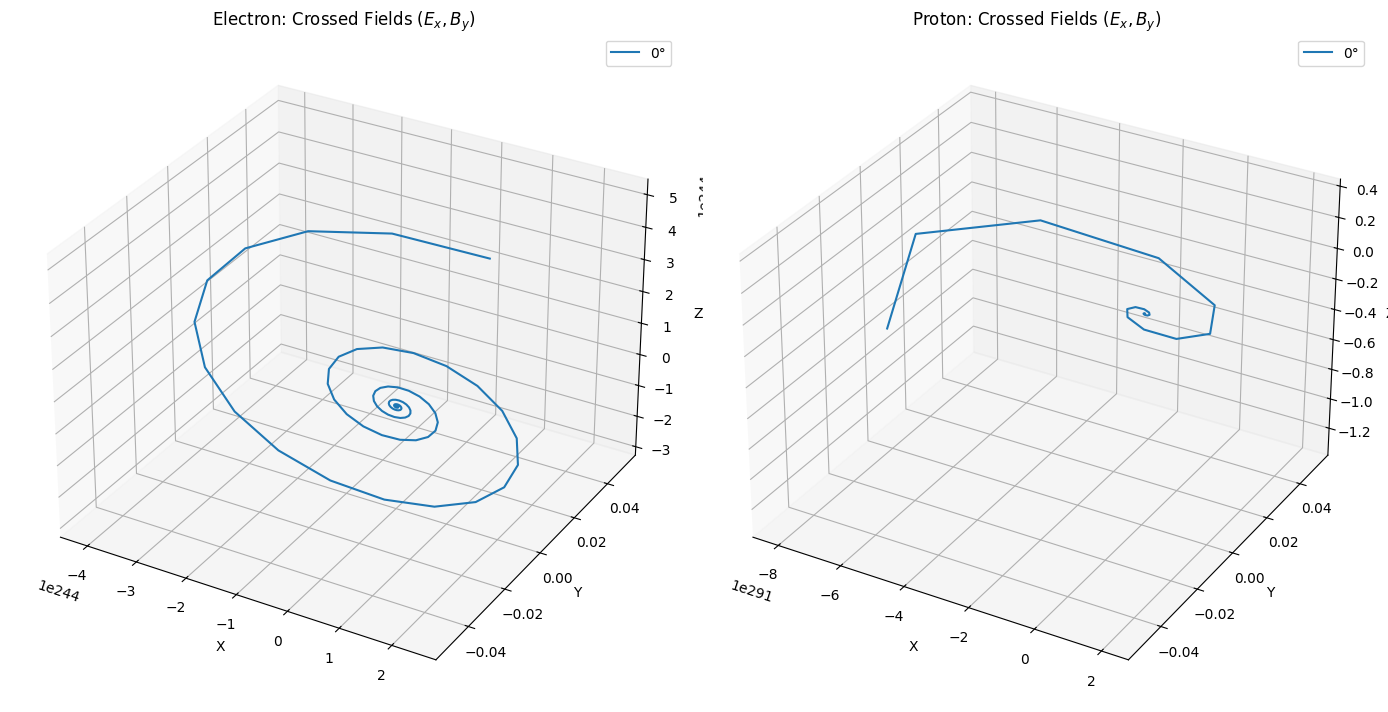

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# CONSTANTS
m_e, q_e = 9.109e-31, -1.602e-19  # Electron
m_p, q_p = 1.672e-27, 1.602e-19   # Proton

# E along X, B along Y
Ex, Ey, Ez = 1000.0, 0.0, 0.0
Bx, By, Bz = 0.0, 1.0, 0.0

v0 = 1000.0
angles = [00
steps = 10000

# simulation
def simulate(q, m, dt, angle_deg):
    theta = np.radians(angle_deg)

    # Initial velocity relative to Z-axis
    vx = v0 * np.sin(theta)
    vy = 0.0
    vz = v0 * np.cos(theta)

    x, y, z = 0.0, 0.0, 0.0


    x_arr = np.zeros(steps)
    y_arr = np.zeros(steps)
    z_arr = np.zeros(steps)

    for i in range(steps):
        #current positions
        x_arr[i], y_arr[i], z_arr[i] = x, y, z

        # Lorentz Force: F = q(E + v x B)
        # Components for E=(Ex,0,0) and B=(0,By,0)
        Fx = q * (Ex + (vy * Bz - vz * By))
        Fy = q * (Ey + (vz * Bx - vx * Bz))
        Fz = q * (Ez + (vx * By - vy * Bx))

        # Euler method
        x = x + vx * dt
        y = y + vy * dt
        z = z + vz * dt

        # Update Velocity SECOND
        vx = vx + (Fx / m) * dt
        vy = vy + (Fy / m) * dt
        vz = vz + (Fz / m) * dt

    return x_arr, y_arr, z_arr

#PLOT
fig = plt.figure(figsize=(14, 7))

# Electron
ax1 = fig.add_subplot(121, projection='3d')
for angle in angles:
    # for Electron we use small dt
    x, y, z = simulate(q_e, m_e, 1e-12, angle)
    ax1.plot(x, y, z, label=f"{angle}°")
ax1.set_title("Electron: Crossed Fields ($E_x, B_y$)")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
ax1.legend()

#Proton
ax2 = fig.add_subplot(122, projection='3d')
for angle in angles:
    # for Proton use larger dt
    x, y, z = simulate(q_p, m_p, 5e-9, angle)
    ax2.plot(x, y, z, label=f"{angle}°")
ax2.set_title("Proton: Crossed Fields ($E_x, B_y$)")
ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")
ax2.legend()

plt.tight_layout()
plt.show()